In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Reviews.csv to Reviews.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ")

Libraries loaded 


In [ ]:
df = pd.read_csv('Reviews.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
# Step 1: Basic info
print("Dataset shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nScore distribution:\n", df['Score'].value_counts())

Dataset shape: (568454, 10)

Null values:
 Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score distribution:
 Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64


In [ ]:
# Step 2: Duplicates remove + null drop
df = df.drop_duplicates(subset=['Text'])
df = df.dropna(subset=['Text', 'Score'])
print("After cleaning shape:", df.shape)

After cleaning shape: (393579, 10)


In [ ]:
import re

def label_v3(row):
    text = str(row['Text'])

    exclamations = text.count('!')
    caps_words = len(re.findall(r'\b[A-Z]{3,}\b', text))
    word_count = len(text.split())

    # Spam words check
    spam_words = ['amazing', 'incredible', 'best ever', 'buy now',
                  'must buy', 'love love', 'perfect perfect', 'awesome awesome']
    spam_count = sum(1 for w in spam_words if w in text.lower())

    # Genuine signals
    genuine_words = ['however', 'although', 'but', 'except', 'quality',
                     'compared', 'weeks', 'months', 'purchased', 'delivered']
    genuine_count = sum(1 for w in genuine_words if w in text.lower())

    fake_score = 0

    if exclamations >= 4: fake_score += 3
    if caps_words >= 3: fake_score += 3
    if spam_count >= 2: fake_score += 3
    if word_count < 10: fake_score += 2
    if genuine_count >= 2: fake_score -= 3  # genuine signal

    return 1 if fake_score >= 4 else 0

df['label'] = df.apply(label_v3, axis=1)
print("Label distribution:")
print(df['label'].value_counts())
print("Fake %:", round(df['label'].mean()*100, 2), "%")

Label distribution:
label
0    390744
1      2835
Name: count, dtype: int64
Fake %: 0.72 %


In [ ]:
df_genuine = df[df['label']==0]
df_fake = df[df['label']==1]

min_size = min(len(df_genuine), len(df_fake), 20000)

df_sample = pd.concat([
    df_genuine.sample(n=min_size, random_state=42),
    df_fake.sample(n=min_size, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Final sample:", df_sample.shape)
print(df_sample['label'].value_counts())

Final sample: (5670, 11)
label
1    2835
0    2835
Name: count, dtype: int64


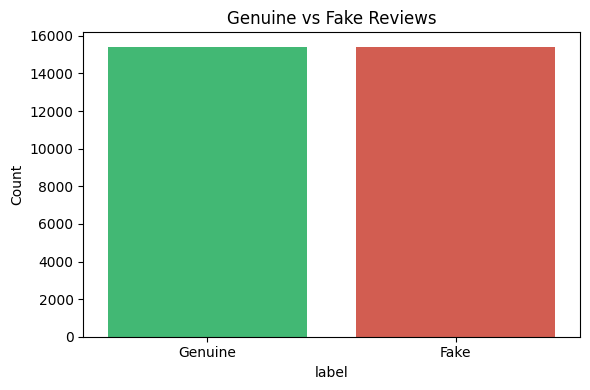

In [ ]:
# Plot 1: Label Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_sample, palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['Genuine', 'Fake'])
plt.title('Genuine vs Fake Reviews')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

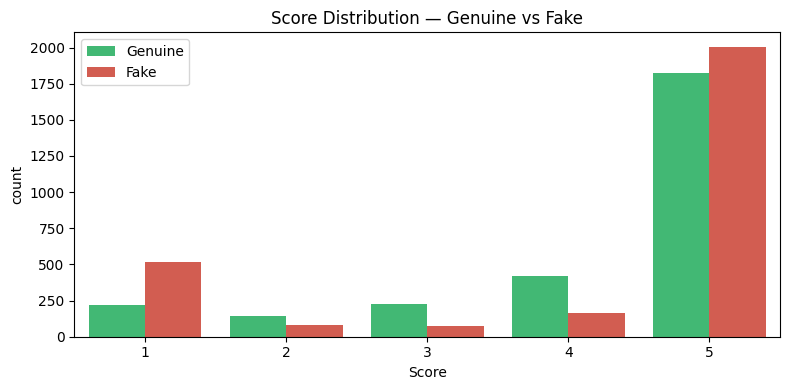

In [ ]:
# Plot 2: Score Distribution by Label
plt.figure(figsize=(8,4))
sns.countplot(x='Score', hue='label', data=df_sample, palette=['#2ecc71','#e74c3c'])
plt.title('Score Distribution — Genuine vs Fake')
plt.legend(['Genuine','Fake'])
plt.tight_layout()
plt.show()

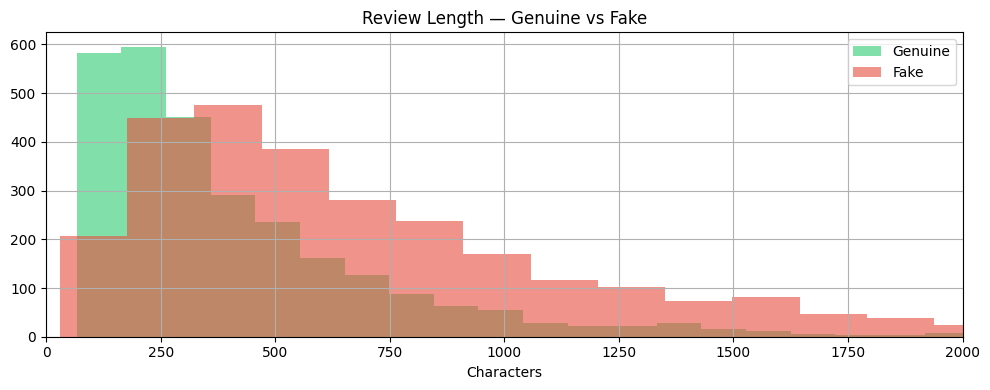

Avg Genuine length: 437
Avg Fake length: 787


In [ ]:
# Plot 3: Review Text Length Analysis
df_sample['text_length'] = df_sample['Text'].apply(len)

plt.figure(figsize=(10,4))
df_sample[df_sample['label']==0]['text_length'].hist(bins=50, alpha=0.6, color='#2ecc71', label='Genuine')
df_sample[df_sample['label']==1]['text_length'].hist(bins=50, alpha=0.6, color='#e74c3c', label='Fake')
plt.xlim(0, 2000)
plt.title('Review Length — Genuine vs Fake')
plt.xlabel('Characters')
plt.legend()
plt.tight_layout()
plt.show()

print("Avg Genuine length:", round(df_sample[df_sample['label']==0]['text_length'].mean()))
print("Avg Fake length:", round(df_sample[df_sample['label']==1]['text_length'].mean()))

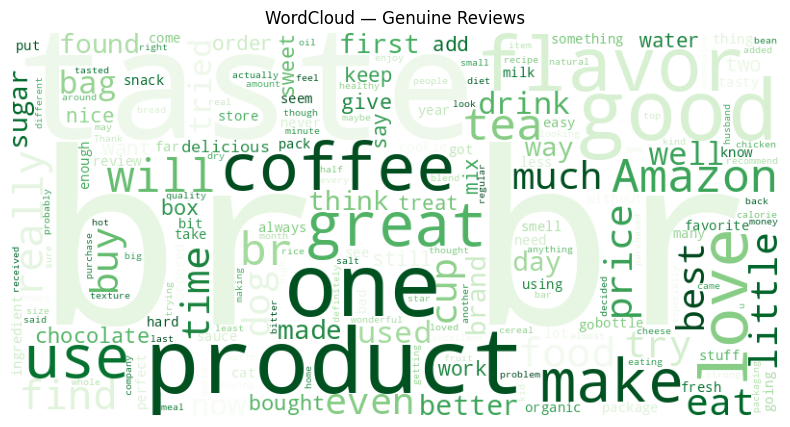

In [ ]:
# Plot 4: WordCloud — Genuine Reviews
from wordcloud import WordCloud

genuine_text = ' '.join(df_sample[df_sample['label']==0]['Text'].astype(str).tolist())
wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(genuine_text)

plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud — Genuine Reviews')
plt.show()

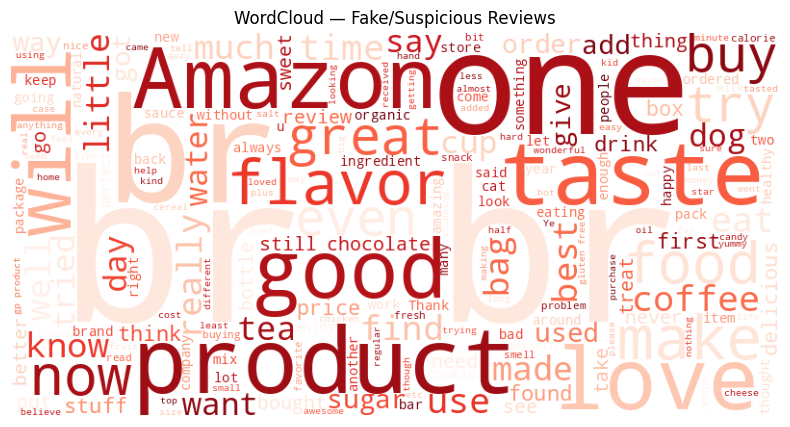

In [ ]:
# Plot 5: WordCloud — Fake/Suspicious Reviews
fake_text = ' '.join(df_sample[df_sample['label']==1]['Text'].astype(str).tolist())
wc2 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)

plt.figure(figsize=(12,5))
plt.imshow(wc2)
plt.axis('off')
plt.title('WordCloud — Fake/Suspicious Reviews')
plt.show()

In [ ]:
# Step 1: Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import re

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLP Libraries ready ✅")

NLP Libraries ready ✅


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Step 2: Text Cleaning Function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+', '', text)               # URLs remove
    text = re.sub(r'[^a-z\s]', '', text)              # special chars remove
    text = re.sub(r'\s+', ' ', text).strip()          # extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print("Testing cleaner:")
print(clean_text("This product is AMAZING!!! Buy it now -> https://amazon.com"))

Testing cleaner:
product amazing buy


In [ ]:
# Step 3: Clean karo — thodi time lagse (50K rows)
print("Cleaning started... (2-3 min lagse)")
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)
print("Text cleaning done ✅")
df_sample[['Text','clean_text']].head(3)

Cleaning started... (2-3 min lagse)
Text cleaning done ✅


,Text,clean_text
0,THIS SIZE IS A GREAT VALUE!!! I AM JUST ONE PE...,size great value one person household drinksbr...
1,This product is bad for you!! I bought this a...,product bad bought assuming stevia raw meant f...
2,I looked into how to duplicate how they make C...,looked duplicate make chais coffee shop clue f...


In [ ]:
# Step 4: Extra Features banavo
print("Features banavva shuru...")

# Sentiment score (TextBlob)
df_sample['sentiment'] = df_sample['Text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Review length
df_sample['text_length'] = df_sample['Text'].apply(len)

# Word count
df_sample['word_count'] = df_sample['Text'].apply(lambda x: len(str(x).split()))

# Exclamation marks count
df_sample['exclamation_count'] = df_sample['Text'].apply(lambda x: str(x).count('!'))

# Capital letters ratio
df_sample['caps_ratio'] = df_sample['Text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)

# Helpfulness ratio (already chhe but recalculate)
df_sample['helpfulness_ratio'] = df_sample['HelpfulnessNumerator'] / (df_sample['HelpfulnessDenominator'] + 1)

print("Extra features done ✅")
print("\nNew columns:", ['sentiment','text_length','word_count','exclamation_count','caps_ratio','helpfulness_ratio'])
df_sample[['sentiment','text_length','word_count','exclamation_count','caps_ratio','label']].head()

Features banavva shuru...
Extra features done ✅

New columns: ['sentiment', 'text_length', 'word_count', 'exclamation_count', 'caps_ratio', 'helpfulness_ratio']


,sentiment,text_length,word_count,exclamation_count,caps_ratio,label
0,1.000000,140,23,8,0.687943,1
1,-0.351564,424,74,4,0.082353,1
2,0.170000,684,136,0,0.029197,0
3,0.178387,846,101,1,0.087367,0
4,0.207833,573,112,0,0.024390,0


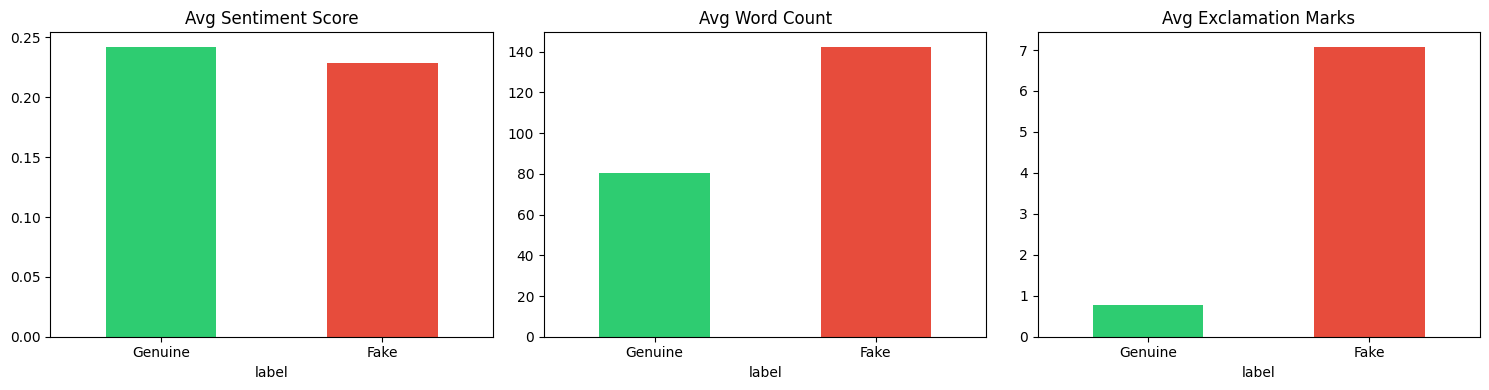

In [ ]:
# Step 5: Feature Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment by label
df_sample.groupby('label')['sentiment'].mean().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], title='Avg Sentiment Score'
)
axes[0].set_xticklabels(['Genuine','Fake'], rotation=0)

# Word count by label
df_sample.groupby('label')['word_count'].mean().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], title='Avg Word Count'
)
axes[1].set_xticklabels(['Genuine','Fake'], rotation=0)

# Exclamation by label
df_sample.groupby('label')['exclamation_count'].mean().plot(
    kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], title='Avg Exclamation Marks'
)
axes[2].set_xticklabels(['Genuine','Fake'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Step 6: TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import numpy as np

# TF-IDF on clean text
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df_sample['clean_text'])

# Extra numeric features
extra_features = df_sample[['sentiment','text_length','word_count',
                             'exclamation_count','caps_ratio','helpfulness_ratio']].values

# Combine TF-IDF + extra features
X = sp.hstack([X_tfidf, sp.csr_matrix(extra_features)])
y = df_sample['label'].values

print("Final Feature Matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("\nPhase 2 Complete ✅ — Ready for ML training!")

Final Feature Matrix shape: (5670, 5006)
Labels shape: (5670,)

Phase 2 Complete ✅ — Ready for ML training!


In [ ]:
# Step 1: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train label balance:", dict(zip(*np.unique(y_train, return_counts=True))))

Train size: (4536, 5006)
Test size: (1134, 5006)
Train label balance: {np.int64(0): np.int64(2268), np.int64(1): np.int64(2268)}


In [ ]:
# Step 2: Model 1 — Logistic Regression (sabse fast)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, lr_pred, target_names=['Genuine','Fake']))
print("ROC-AUC Score:", round(lr_auc, 4))

Training Logistic Regression...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

     Genuine       1.00      0.94      0.97       567
        Fake       0.94      1.00      0.97       567

    accuracy                           0.97      1134
   macro avg       0.97      0.97      0.97      1134
weighted avg       0.97      0.97      0.97      1134

ROC-AUC Score: 0.9838


In [ ]:
# Step 3: Model 2 — Random Forest
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest... (3-4 min lagse)")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_pred, target_names=['Genuine','Fake']))
print("ROC-AUC Score:", round(rf_auc, 4))

Training Random Forest... (3-4 min lagse)

--- Random Forest Results ---
              precision    recall  f1-score   support

     Genuine       1.00      0.94      0.97       567
        Fake       0.95      1.00      0.97       567

    accuracy                           0.97      1134
   macro avg       0.97      0.97      0.97      1134
weighted avg       0.97      0.97      0.97      1134

ROC-AUC Score: 0.9949


In [ ]:
# Step 4: Model 3 — XGBoost (best performer)
from xgboost import XGBClassifier

print("Training XGBoost... (2-3 min lagse)")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print("\n--- XGBoost Results ---")
print(classification_report(y_test, xgb_pred, target_names=['Genuine','Fake']))
print("ROC-AUC Score:", round(xgb_auc, 4))

Training XGBoost... (2-3 min lagse)

--- XGBoost Results ---
              precision    recall  f1-score   support

     Genuine       0.99      0.98      0.98       567
        Fake       0.98      0.99      0.99       567

    accuracy                           0.99      1134
   macro avg       0.99      0.99      0.99      1134
weighted avg       0.99      0.99      0.99      1134

ROC-AUC Score: 0.9953


                 Model  F1-Score  ROC-AUC
0  Logistic Regression    0.9675   0.9838
1        Random Forest    0.9717   0.9949
2              XGBoost    0.9851   0.9953


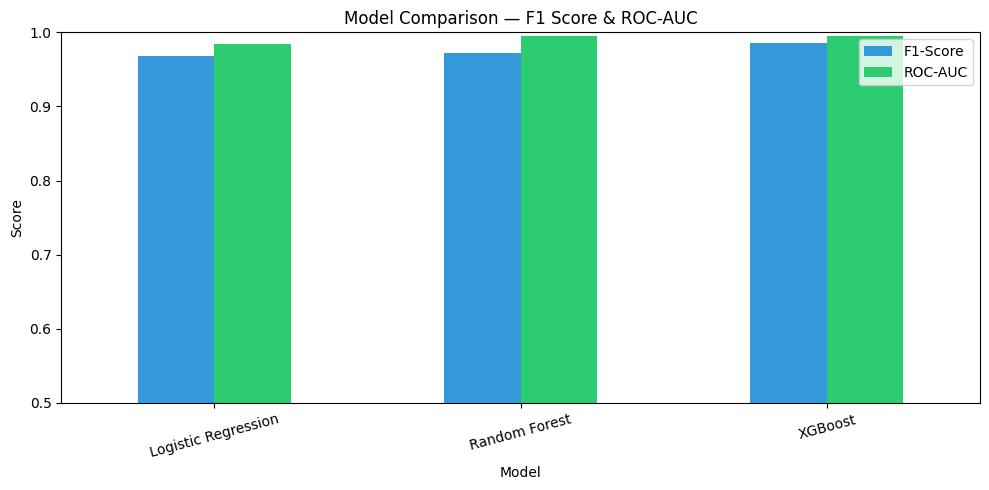

In [ ]:
# Step 5: Model Comparison
from sklearn.metrics import f1_score

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1-Score': [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, rf_pred), 4),
        round(f1_score(y_test, xgb_pred), 4)
    ],
    'ROC-AUC': [
        round(lr_auc, 4),
        round(rf_auc, 4),
        round(xgb_auc, 4)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

# Bar chart
results_df.plot(x='Model', kind='bar', figsize=(10,5),
                color=['#3498db','#2ecc71'], rot=15)
plt.title('Model Comparison — F1 Score & ROC-AUC')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Best Model save karo
import joblib

# Best model select (usually XGBoost)
best_model = xgb
joblib.dump(best_model, 'fake_review_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Extra feature scaler banavo
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)
scaler.fit(sp.csr_matrix(extra_features))
joblib.dump(scaler, 'scaler.pkl')

print("Model saved ✅  fake_review_model.pkl")
print("Vectorizer saved ✅  tfidf_vectorizer.pkl")
print("Scaler saved ✅  scaler.pkl")

Model saved ✅  fake_review_model.pkl
Vectorizer saved ✅  tfidf_vectorizer.pkl
Scaler saved ✅  scaler.pkl


In [ ]:
# Step 7: Files download karo local machine pe
from google.colab import files

files.download('fake_review_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('scaler.pkl')

print("Download complete! 3 files tara laptop ma aavsi ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete! 3 files tara laptop ma aavsi ✅
